# Проект: разработка модели для прогнозирования оттока клиентов оператора связи "ТелеДом"

# Содержание

1. Введение и подготовка окружения
2. Загрузка и предобработка данных
3. Объединение таблиц
4. Исследовательский и корреляционный анализ данных
5. Подготовка данных и обучение моделей
6. Выбор лучшей модели и интерпретация результатов
7. Общий вывод и рекомендации заказчику

## Введение и подготовка окружения

**Описание проекта:** 

Оператор связи "ТелеДом" стремится снизить отток клиентов, предлагая специальные условия и промокоды тем, кто планирует прекратить использование услуг. Для этого необходимо заранее определять пользователей, которые с высокой вероятностью разорвут договор. В проекте предстоит разработать и обучить модель машинного обучения, способную прогнозировать отток клиентов на основе исторических данных о договорах, услугах и персональных характеристиках абонентов.

**Описание данных:**

- файл contract_new.csv содержит информацию о договоре (идентификатор абонента, даты начала и окончания действия, тип оплаты, расходы абонентов и пр.);
- файл personal_new.csv содержит персональные данные клиентов;
- файл personal_new.csv содержит информацию об интернет-услугах;
- файл phone_new.csv содержит информацию об услугах телефонии.

**Цель исследования:** 

Построить модель машинного обучения, способную предсказывать вероятность расторжения договора клиентом компании "ТелеДом". Минимальный порог качества модели — значение метрики ROC-AUC не ниже 0.85.

**Ход исследования:**

- загрузка и первичный осмотр данных;
- исследовательский анализ каждого набора данных и предобработка;
- объединение данных;
- исследовательский анализ и предобработка данных объединённого датафрейма, выбор значимых признаков;
- подготовка данных с использованием пайплайнов, кодирование и масштабирование признаков;
- обучение нескольких моделей, подбор гиперпараметров, расчет метрик качества и выбор лучшей модели;
- анализ важности признаков и интерпретация результатов.

**Общий вывод:** Резюмирование этапов исследования, определение наилучшей модели по метрике ROC-AUC, анализ ключевых факторов, влияющих на отток, и формулировка бизнес-рекомендаций по снижению числа уходящих клиентов.

**Подготовка окружения**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install phik -q
import phik

!pip install -U scikit-learn -q
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

!pip install shap -q
import shap

## Загрузка и предобработка данных

### Информация о договорах

In [2]:
contract = pd.read_csv('/datasets/contract_new.csv')
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


В датафрейме содержится информация о договорах, он включает в себя столбцы с идентификатором клиента, датами начала  и окончания договора (если договор не расторгнут, в столбце EndDate указано "No"), типом платежей, типом расчетного листа, платежным методом и расходами (месячными и суммарными).

In [3]:
# Переименование столбцов в соответствии с PEP
contract.columns = [
    'customer_id', 
    'begin_date', 
    'end_date', 
    'contract_type', 
    'paperless_billing',
    'payment_method',
    'monthly_charges',
    'total_charges'
]

In [4]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   begin_date         7043 non-null   object 
 2   end_date           7043 non-null   object 
 3   contract_type      7043 non-null   object 
 4   paperless_billing  7043 non-null   object 
 5   payment_method     7043 non-null   object 
 6   monthly_charges    7043 non-null   float64
 7   total_charges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


Датафрейм содержит 8 колонок и 7043 записи. В некоторых столбцах требуется преобразование типов данных (begin_date, end_date и total_charges).

In [5]:
# Проверка значений customer_id на уникальность
len(contract['customer_id']) == contract['customer_id'].nunique()

True

Количество строк и суммарное количество уникальных значений совпали, следовательно, идентификаторы не дублируются.

In [6]:
# Сделаем customer_id индексами
contract = contract.set_index('customer_id')

In [7]:
contract.head()

,begin_date,end_date,contract_type,paperless_billing,payment_method,monthly_charges,total_charges
customer_id,,,,,,,
7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


In [8]:
# Приведем begin_date к корректному формату
contract['begin_date'] = pd.to_datetime(contract['begin_date'])

In [9]:
contract['begin_date'].describe(datetime_is_numeric=True)

count                             7043
mean     2017-04-30 13:01:50.918642688
min                2013-10-01 00:00:00
25%                2015-06-01 00:00:00
50%                2017-09-01 00:00:00
75%                2019-04-01 00:00:00
max                2020-02-01 00:00:00
Name: begin_date, dtype: object

Самая ранняя дата заключения — 01.10.2013, самая поздняя — 01.02.2020. Аномальных значений нет.

У договоров, не расторгнутых на текущий момент, в колонке end_date указано значение "No". Чтобы привести значения в столбце к формату даты, заменим строчные значения на пропуски.

In [10]:
contract['end_date'] = pd.to_datetime(contract['end_date'], errors='coerce')

In [11]:
contract['end_date'].describe(datetime_is_numeric=True)

count                             1101
mean     2018-03-12 18:21:15.204359680
min                2014-06-01 00:00:00
25%                2017-05-01 00:00:00
50%                2018-06-01 00:00:00
75%                2019-04-01 00:00:00
max                2020-01-01 00:00:00
Name: end_date, dtype: object

Самая ранняя дата расторжения — 01.06.2014, самая поздняя — 01.01.2020. Аномальных значений нет.

Всего в выборке 1101 расторгнутый договор (около 16%).

Проверим, что во всех расторгнутых контрактах дата заключения предшествует дате расторжения.

In [12]:
(contract['end_date'] >= contract['begin_date']).sum()

1101

Значения совпали, аномалий нет.

In [13]:
contract['end_date'].isna().sum()

5942

После замены в колонке end_date 5942 пропуска, то есть в выборке 5942 продолжавших действовать на 01.02.2020 договора (около 84% от общего количества).

В нашей задаче целевым признаком является факт расторжения договора. Добавим столбец, в котором запишем 0, если договор продолжал действовать на 01.02.2020 или 1, если договор был расторгнут.

In [14]:
contract.insert(0, 'is_ended', contract['end_date'].notna().astype(int))

In [15]:
len(contract['is_ended']) - contract['is_ended'].sum()

5942

Значения совпали, столбец заполнен корректно.



Чтобы рассчитать продолжительность договоров, заполним пропуски в столбце end_date датой, на которую актуальна выгрузка — 1 февраля 2020 года.

In [16]:
contract['end_date'] = contract['end_date'].fillna(pd.to_datetime('2020-02-01'))

In [17]:
# Добавление столбца с продолжительностью действия договора
contract['duration_days'] = (contract['end_date'] - contract['begin_date']).dt.days

In [18]:
contract.head(10)

,is_ended,begin_date,end_date,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,duration_days
customer_id,,,,,,,,,
7590-VHVEG,0,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,31
5575-GNVDE,0,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,1036
3668-QPYBK,0,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,123
7795-CFOCW,0,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.6,1371
9237-HQITU,0,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.5,153
9305-CDSKC,0,2019-03-01,2020-02-01,Month-to-month,Yes,Electronic check,99.65,1150.96,337
1452-KIOVK,0,2018-04-01,2020-02-01,Month-to-month,Yes,Credit card (automatic),89.10,2058.21,671
6713-OKOMC,0,2019-04-01,2020-02-01,Month-to-month,No,Mailed check,29.75,300.48,306
7892-POOKP,0,2017-07-01,2020-02-01,Month-to-month,Yes,Electronic check,104.80,3573.68,945


Продолжительность посчитана корректно.

In [19]:
print(contract['contract_type'].unique())
print(contract['paperless_billing'].unique())
print(contract['payment_method'].unique())

['Month-to-month' 'One year' 'Two year']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


Contract_type и payment_method — категориальные признаки, paperless_billing — категориальный бинарный. Неявные дубликаты отсутствуют, аномальных значений нет.

In [20]:
# Заменим значения 'Yes' и 'No' нулями и единицами
contract['paperless_billing'] = contract['paperless_billing'].replace({'Yes': 1, 'No': 0})

In [21]:
contract.head()

,is_ended,begin_date,end_date,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,duration_days
customer_id,,,,,,,,,
7590-VHVEG,0,2020-01-01,2020-02-01,Month-to-month,1,Electronic check,29.85,31.04,31
5575-GNVDE,0,2017-04-01,2020-02-01,One year,0,Mailed check,56.95,2071.84,1036
3668-QPYBK,0,2019-10-01,2020-02-01,Month-to-month,1,Mailed check,53.85,226.17,123
7795-CFOCW,0,2016-05-01,2020-02-01,One year,0,Bank transfer (automatic),42.30,1960.6,1371
9237-HQITU,0,2019-09-01,2020-02-01,Month-to-month,1,Electronic check,70.70,353.5,153


In [22]:
# Приведем столбец total_charges к числовому типу.
# Нечисловые значения заменим на NaN.
contract['total_charges'] = pd.to_numeric(contract['total_charges'], errors='coerce')

In [23]:
contract['total_charges'].isna().sum()

11

In [24]:
contract.query('total_charges.isna()')

,is_ended,begin_date,end_date,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,duration_days
customer_id,,,,,,,,,
4472-LVYGI,0,2020-02-01,2020-02-01,Two year,1,Bank transfer (automatic),52.55,NaN,0
3115-CZMZD,0,2020-02-01,2020-02-01,Two year,0,Mailed check,20.25,NaN,0
5709-LVOEQ,0,2020-02-01,2020-02-01,Two year,0,Mailed check,80.85,NaN,0
4367-NUYAO,0,2020-02-01,2020-02-01,Two year,0,Mailed check,25.75,NaN,0
1371-DWPAZ,0,2020-02-01,2020-02-01,Two year,0,Credit card (automatic),56.05,NaN,0
7644-OMVMY,0,2020-02-01,2020-02-01,Two year,0,Mailed check,19.85,NaN,0
3213-VVOLG,0,2020-02-01,2020-02-01,Two year,0,Mailed check,25.35,NaN,0
2520-SGTTA,0,2020-02-01,2020-02-01,Two year,0,Mailed check,20.00,NaN,0
2923-ARZLG,0,2020-02-01,2020-02-01,One year,1,Mailed check,19.70,NaN,0


Пропуски в столбце total_charges появились в строках с договорами, заключенными в день выгрузки датасета, по которым не прошло еще ни одного платежа. Такие договоры не будут информативными для модели, удалим строки с ними.

In [25]:
contract = contract.dropna(subset=['total_charges'])

Проверим датасет на наличие пропусков.

In [26]:
contract.isna().sum()

is_ended             0
begin_date           0
end_date             0
contract_type        0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
duration_days        0
dtype: int64

In [27]:
contract.describe()

,is_ended,paperless_billing,monthly_charges,total_charges,duration_days
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.156570,0.592719,64.798208,2118.621822,899.961320
std,0.363421,0.491363,30.085974,2112.736199,682.738777
min,0.000000,0.000000,18.250000,19.050000,28.000000
25%,0.000000,0.000000,35.587500,439.745000,276.000000
50%,0.000000,1.000000,70.350000,1345.275000,761.000000
75%,0.000000,1.000000,89.862500,3239.317500,1461.000000
max,1.000000,1.000000,118.750000,9221.380000,2314.000000


При анализе основных показателей аномальных значений не обнаружено. Более детально рассмотрим показатели на этапе EDA.

In [28]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   is_ended           7032 non-null   int64         
 1   begin_date         7032 non-null   datetime64[ns]
 2   end_date           7032 non-null   datetime64[ns]
 3   contract_type      7032 non-null   object        
 4   paperless_billing  7032 non-null   int64         
 5   payment_method     7032 non-null   object        
 6   monthly_charges    7032 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   duration_days      7032 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(3), object(2)
memory usage: 549.4+ KB


Типы данных корректны.

### Информация о пользователях

In [29]:
clients = pd.read_csv('/datasets/personal_new.csv')
clients.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Датафрейм содержит персональные данные клиентов — идентификатор, пол, является ли абонент пенсионером, есть ли у абонента супруг или супруга, есть ли у абонента дети.

In [30]:
# Переименование столбцов в соответствии с PEP
clients.columns = [
    'customer_id', 
    'gender', 
    'senior_citizen', 
    'partner', 
    'dependents'
]

In [31]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   int64 
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


Датафрейм содержит 5 колонок и 7043 записи.

In [32]:
# Проверка значений customer_id на уникальность
len(clients['customer_id']) == clients['customer_id'].nunique()

True

Количество строк и суммарное количество уникальных значений совпали, следовательно, идентификаторы не дублируются.

In [33]:
# Сделаем customer_id индексами.
clients = clients.set_index('customer_id')

In [34]:
clients.head()

,gender,senior_citizen,partner,dependents
customer_id,,,,
7590-VHVEG,Female,0,Yes,No
5575-GNVDE,Male,0,No,No
3668-QPYBK,Male,0,No,No
7795-CFOCW,Male,0,No,No
9237-HQITU,Female,0,No,No


In [35]:
print(clients['gender'].unique())
print(clients['senior_citizen'].unique())
print(clients['partner'].unique())
print(clients['dependents'].unique())

['Female' 'Male']
[0 1]
['Yes' 'No']
['No' 'Yes']


Столбцы содержат категориальные бинарные признаки. Неявные дубликаты отсутствуют.

In [36]:
# Заменим значения 'Yes' и 'No' нулями и единицами.
clients = clients.replace({'Yes': 1, 'No': 0})

In [37]:
clients.head()

,gender,senior_citizen,partner,dependents
customer_id,,,,
7590-VHVEG,Female,0,1,0
5575-GNVDE,Male,0,0,0
3668-QPYBK,Male,0,0,0
7795-CFOCW,Male,0,0,0
9237-HQITU,Female,0,0,0


In [38]:
clients.isna().sum()

gender            0
senior_citizen    0
partner           0
dependents        0
dtype: int64

### Информация об интернет-услугах

In [39]:
i_services = pd.read_csv('/datasets/internet_new.csv')
i_services.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


Датафрейм содержит информацию о типе подключения, подключенных пользователями интернет-услугах (блокировка опасных сайтов, облачное хранилище файлов для резервного копирования данных, антивирус, выделенная линия технической поддержки, стриминговое телевидение, каталог фильмов), а также идентификаторы пользователей.

In [40]:
# Переименование столбцов в соответствии с PEP
i_services.columns = [
    'customer_id', 
    'internet_service', 
    'online_security', 
    'online_backup', 
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies'
]

In [41]:
i_services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


Датафрейм содержит 8 колонок и 5517 записей.

In [42]:
# Проверка значений customer_id на уникальность
len(i_services['customer_id']) == i_services['customer_id'].nunique()

True

Количество строк и суммарное количество уникальных значений совпали, следовательно, идентификаторы не дублируются.

In [43]:
i_services = i_services.set_index('customer_id')

In [44]:
i_services.head()

,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
customer_id,,,,,,,
7590-VHVEG,DSL,No,Yes,No,No,No,No
5575-GNVDE,DSL,Yes,No,Yes,No,No,No
3668-QPYBK,DSL,Yes,Yes,No,No,No,No
7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
9237-HQITU,Fiber optic,No,No,No,No,No,No


In [45]:
print(i_services['internet_service'].unique())
print(i_services['online_security'].unique())
print(i_services['online_backup'].unique())
print(i_services['device_protection'].unique())
print(i_services['tech_support'].unique())
print(i_services['streaming_tv'].unique())
print(i_services['streaming_movies'].unique())

['DSL' 'Fiber optic']
['No' 'Yes']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']


Столбец internet_service содержит данные о типе интернет-подключения. Это категориальный признак, несмотря на то, что значений всего два, бинарным он не является. Остальные столбцы содержат категориальные бинарные признаки (подключены услуги или нет).

Неявные дубликаты отсутствуют.

In [46]:
# Заменим значения 'Yes' и 'No' нулями и единицами.
i_services = i_services.replace({'Yes': 1, 'No': 0})

In [47]:
extra_i_serv = [
    'online_security', 
    'online_backup', 
    'device_protection', 
    'tech_support', 
    'streaming_tv', 
    'streaming_movies'
]

In [48]:
# Добавление столбца с количеством подключеннных услуг
i_services['serv_number'] = i_services[extra_i_serv].sum(axis=1)

In [49]:
i_services.head()

,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,serv_number
customer_id,,,,,,,,
7590-VHVEG,DSL,0,1,0,0,0,0,1
5575-GNVDE,DSL,1,0,1,0,0,0,2
3668-QPYBK,DSL,1,1,0,0,0,0,2
7795-CFOCW,DSL,1,0,1,1,0,0,3
9237-HQITU,Fiber optic,0,0,0,0,0,0,0


In [50]:
i_services.isna().sum()

internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
serv_number          0
dtype: int64

### Информация об услугах телефонии

In [51]:
t_services = pd.read_csv('/datasets/phone_new.csv')
t_services.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


Датафрейм содержит идентификаторы пользователей и информацию о том, подключен ли телефон абонента к нескольким линиям одновременно.

In [52]:
# Переименование столбцов в соответствии с PEP
t_services.columns = [
    'customer_id', 
    'multiple_lines'
]

In [53]:
t_services.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


Датафрейм содержит 2 колонки и 6361 запись.

In [54]:
# Проверка значений customer_id на уникальность
len(t_services['customer_id']) == t_services['customer_id'].nunique()

True

Количество строк и суммарное количество уникальных значений совпали, следовательно, идентификаторы не дублируются.

In [55]:
t_services = t_services.set_index('customer_id')

In [56]:
t_services.head()

,multiple_lines
customer_id,
5575-GNVDE,No
3668-QPYBK,No
9237-HQITU,No
9305-CDSKC,Yes
1452-KIOVK,Yes


In [57]:
t_services['multiple_lines'].unique()

array(['No', 'Yes'], dtype=object)

Это категориальный бинарный признак. Неявные дубликаты отсутствуют.

In [58]:
# Заменим значения 'Yes' и 'No' нулями и единицами.
t_services = t_services.replace({'Yes': 1, 'No': 0})

In [59]:
t_services.head()

,multiple_lines
customer_id,
5575-GNVDE,0
3668-QPYBK,0
9237-HQITU,0
9305-CDSKC,1
1452-KIOVK,1


In [60]:
t_services.isna().sum()

multiple_lines    0
dtype: int64

### Вывод по разделу

На данном этапе были загружены и изучены четыре исходных файла: contract_new.csv, personal_new.csv, internet_new.csv и phone_new.csv.

В ходе анализа:

- во всех таблицах столбцы переименованы в соответствии со стандартом PEP 8;
- подтверждено, что идентификаторы клиентов (customer_id) уникальны, пропусков нет;
- в датафрейме contract выполнено преобразование типов данных: даты приведены к формату datetime, расходы — к числовому типу float;
- создан бинарный целевой признак is_ended, отражающий факт расторжения договора, рассчитана продолжительность договора (duration_days);
- пропуски в end_date заменены датой актуальности выгрузки (1 февраля 2020 года);
- выявлено, что около 16% договоров были расторгнуты к указанной дате;
- пропуски в total_charges заменены нулями — они соответствуют договорам, заключенным в день выгрузки, по которым еще не было платежей;
- в остальных наборах данных проведена проверка типов и уникальных значений: все признаки корректны, неявных дубликатов и аномалий не выявлено.

Таким образом, данные успешно загружены и приведены к корректным форматам. Все таблицы готовы к объединению по ключу customer_id и дальнейшему исследовательскому анализу.

## Объединение таблиц

Перед объединением отобразим размеры исходных датафреймов, чтобы потом проверить результат

In [61]:
print(contract.shape)
print(clients.shape)
print(i_services.shape)
print(t_services.shape)

(7032, 9)
(7043, 4)
(5517, 8)
(6361, 1)


Первая таблица содержит 7032 записи (из-за удаления контрактов, заключенных в день выгрузки датасета), вторая —  полный список клиентов, в третьей таблице только те клиенты, которые пользуются интернетом, в четвертой — телефоном. Идентификаторы пользователей — это индексы, поэтому для объединения будем использовать метод join с настройкой how='left'.

Объединенный датафрейм должен содержать 7032 строки и 22 колонки.

In [62]:
df_full = contract.join(clients, how='left')
df_full = df_full.join(i_services, how='left')
df_full = df_full.join(t_services, how='left')

После объединения таблиц проверим размер и структуру итогового датафрейма, чтобы убедиться в корректности объединения и отсутствии потерь данных.

In [63]:
df_full.shape

(7032, 22)

In [64]:
df_full.head()

,is_ended,begin_date,end_date,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,duration_days,gender,...,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,serv_number,multiple_lines
customer_id,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,2020-01-01,2020-02-01,Month-to-month,1,Electronic check,29.85,31.04,31,Female,...,0,DSL,0.0,1.0,0.0,0.0,0.0,0.0,1.0,NaN
5575-GNVDE,0,2017-04-01,2020-02-01,One year,0,Mailed check,56.95,2071.84,1036,Male,...,0,DSL,1.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0
3668-QPYBK,0,2019-10-01,2020-02-01,Month-to-month,1,Mailed check,53.85,226.17,123,Male,...,0,DSL,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0
7795-CFOCW,0,2016-05-01,2020-02-01,One year,0,Bank transfer (automatic),42.30,1960.60,1371,Male,...,0,DSL,1.0,0.0,1.0,1.0,0.0,0.0,3.0,NaN
9237-HQITU,0,2019-09-01,2020-02-01,Month-to-month,1,Electronic check,70.70,353.50,153,Female,...,0,Fiber optic,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
df_full.isna().sum()

is_ended                0
begin_date              0
end_date                0
contract_type           0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
duration_days           0
gender                  0
senior_citizen          0
partner                 0
dependents              0
internet_service     1520
online_security      1520
online_backup        1520
device_protection    1520
tech_support         1520
streaming_tv         1520
streaming_movies     1520
serv_number          1520
multiple_lines        680
dtype: int64

Размер и структура датафрейма соответствуют ожидаемым. В результате объединения появились пропуски в нескольких столбцах в тех строках, где содержатся данные клиентов, которые отсутствуют в датафреймах i_services и t_services.

Проверим, что эти множества не пересекаются, то есть в итоговой таблице нет клиентов, у которых не подключены ни интернет, ни телефон.

In [66]:
df_full.query('internet_service.isna() and multiple_lines.isna()').shape[0]

0

Таких строк нет.

Пропуски в колонках internet_service и multiple_lines заполним заглушками 'None', а в колонках с интернет-услугами — нулями.

In [67]:
df_full['internet_service'] = df_full['internet_service'].fillna('None')

In [68]:
df_full['multiple_lines'] = df_full['multiple_lines'].fillna('None').astype(str)

In [69]:
df_full[extra_i_serv + ['serv_number']] = df_full[extra_i_serv + ['serv_number']].fillna(0).astype(int)

In [70]:
df_full.isna().sum()

is_ended             0
begin_date           0
end_date             0
contract_type        0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
duration_days        0
gender               0
senior_citizen       0
partner              0
dependents           0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
serv_number          0
multiple_lines       0
dtype: int64

In [71]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   is_ended           7032 non-null   int64         
 1   begin_date         7032 non-null   datetime64[ns]
 2   end_date           7032 non-null   datetime64[ns]
 3   contract_type      7032 non-null   object        
 4   paperless_billing  7032 non-null   int64         
 5   payment_method     7032 non-null   object        
 6   monthly_charges    7032 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   duration_days      7032 non-null   int64         
 9   gender             7032 non-null   object        
 10  senior_citizen     7032 non-null   int64         
 11  partner            7032 non-null   int64         
 12  dependents         7032 non-null   int64         
 13  internet_service   7032 non-null   object        
 14

Пропусков нет, типы данных корректны.

### Вывод по разделу

На данном этапе мы объединили исходные датафреймы по индексам (customer_id) методом left join.

Итоговый датафрейм содержит 22 столбца и 7032 строк.

После объединения возникли пропуски в полях, относящихся к интернет- и телефонным услугам для клиентов без соответствующих подписок.

Проверка показала, что в датафрейме нет клиентов одновременно без интернета и без телефонии (0 строк с пропусками в обоих блоках).

В ходе обработки пропусков:
- в столбцах internet_service и multiple_lines заполнены заглушками 'None';
- в столбцах с признаками наличия подключенных интернет-услуги и их количеством заполнены 0 и приведены к int.

В результате пропусков нет, типы данных приведены к целевым (datetime для дат, float/int для числовых, object для категориальных, int для бинарных).

Датафрейм готов к дальнейшему исследовательскому и корреляционному анализу.

## Исследовательский и корреляционный анализ данных

### Корреляционный анализ

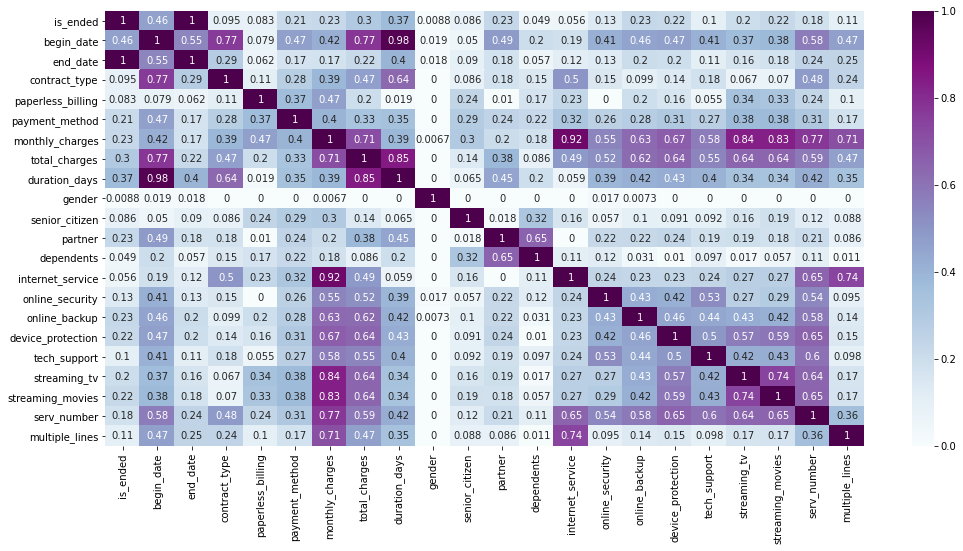

In [72]:
# Рассчитаем Фи коэффициенты для категориальных признаков.
plt.figure(figsize=(17, 8))
sns.heatmap(df_full.phik_matrix(
    interval_cols=['monthly_charges', 'total_charges', 'duration_days']), 
            annot=True, cmap='BuPu')
plt.show()

1. Даты и длительность

Корреляция целевого признака и даты окончания контракта весьма высокая (Фи-к = 1). Это явная утечка данных: действующие контракты в датасете имеют дату окончания 01.02.2020, у завершенных дата отличается. Этот признак следует удалить.

Целевой признак имеет умеренную корреляцию с датой начала контракта (Фи-к = 0.46) и продолжительностью (Фи-к = 0.37). При этом, данные входные признаки мультиколлинеарны (Фи-к = 0.98), один из них необходимо удалить.

Дата начала контракта — псевдопризнак: он не отражает поведение клиента. Кроме того, если потом появятся новые клиенты (с более свежими begin_date), модель будет ошибаться, потому что таких значений не было в обучающей выборке.

Признак duration_days имеет умеренную связь с целевым (Фи-к = 0.37). Продолжительность контракта — более содержательный и интерпретируемый признак. Он отражает, как долго клиент остается в компании — именно это важно для прогноза оттока. Также, признак не зависит от конкретной даты выгрузки данных — только от разницы между началом и концом договора. 

2. Категориальные признаки контрактов

Корреляция с целевым признаком:
- payment_method — слабая (Фи-к = 0.21);
- contract_type — слабая (Фи-к = 0.095);
- paperless_billing — слабая (Фи-к = 0.083).

Мультиколлинеарности с прочими входными признаками не наблюдается. 

Несмотря на слабую связь, стоит оставить эти признаки, так как это независимые аспекты, которые могут объяснять отток.

3. Финансовые признаки контрактов

Корреляция с целевым признаком:
- monthly_charges — слабая (Фи-к = 0.23);
- total_charges — слабая (Фи-к = 0.3).

Обе переменные отражают финансовую нагрузку клиента. 
Признак total_charges имеет закономерно высокую степень связи с duration_days (Фи-к = 0.85) и с monthly_charges (Фи-к = 0.71). Хотя эти значения ниже порога мультиколлинеарности (0.9), признаки частично дублируют друг друга: чем дольше действует договор и чем выше ежемесячный платеж, тем выше суммарные расходы клиента.

Признак monthly_charges мультиколлинеарен типу интернет-подключения (internet_service, Фи-к = 0.92). Это закономерно: ежемесячная плата напрямую определяется тем, подключен ли интернет и какой тип соединения выбран (DSL или оптоволокно). Признак internet_service имеет гораздо более слабую связь с целевым (Фи-к = 0.056), поэтому для устранения мультиколлинеарности лучше отказаться от него.

С учетом этого, в модели лучше использовать признак monthly_charges, а признаки total_charges и internet_service удалить.

4. Персональные признаки клиентов

Связь с целевым признаком слабая:
- gender — практически отсутствует (Фи-к = 0.009);
- senior_citizen — слабая (Фи-к = 0.086);
- partner — слабая (Фи-к = 0.23);
- dependents — очень слабая (Фи-к = 0.049).

Все эти признаки, кроме gender, можно оставить — они отражают социальные особенности клиентов и потенциально влияют на поведение. Признак gender следует удалить как неинформативный.

5. Интернет-услуги

Связь с целевым признаком:
- internet_service — очень слабая (Фи-к = 0.056, удаляемый по причине мультиколлинеарности признак);
- дополнительные сервисы (online_security, online_backup, device_protection, tech_support, streaming_tv, streaming_movies) — слабая (Фи-к 0.1–0.23);
- serv_number — слабая (Фи-к = 0.18).

Между самими сервисами наблюдаются умеренные и высокие корреляции (до 0.74). Это указывает на частое совместное подключение услуг одними клиентами. Для снижения избыточности оставим агрегированный единый признак serv_number (количество подключенных услуг), а исходные бинарные поля удалим.

6. Телефонные услуги

Связь признка multiple_lines с целевым признаком слабая (Фи-к = 0.11). Мультиколлинеарности с прочими входными признаками не наблюдается. 

Вывод:
- ряд признаков необходимо удалить для исключения дублирования, мультиколлинеарности, утечки данных и в связи с неинформативностью;
- наиболее значимые признаки для прогноза оттока клиентов: duration_days, monthly_charges, partner, payment_method, serv_number и multiple_lines;
- прочие признаки со слабой корреляцией не стоит удалять, потому что они могут вносить вклад в предсказание в сочетании с другими.

In [73]:
# Список удаляемых колонок
cols_to_drop = [
    'end_date', 
    'begin_date', 
    'total_charges', 
    'gender',
    'internet_service', 
    'online_security', 
    'online_backup', 
    'device_protection', 
    'tech_support', 
    'streaming_tv', 
    'streaming_movies'
]

In [74]:
df_clean = df_full.drop(columns=cols_to_drop, axis=1)

In [75]:
df_clean.head()

,is_ended,contract_type,paperless_billing,payment_method,monthly_charges,duration_days,senior_citizen,partner,dependents,serv_number,multiple_lines
customer_id,,,,,,,,,,,
7590-VHVEG,0,Month-to-month,1,Electronic check,29.85,31,0,1,0,1,None
5575-GNVDE,0,One year,0,Mailed check,56.95,1036,0,0,0,2,0.0
3668-QPYBK,0,Month-to-month,1,Mailed check,53.85,123,0,0,0,2,0.0
7795-CFOCW,0,One year,0,Bank transfer (automatic),42.30,1371,0,0,0,3,None
9237-HQITU,0,Month-to-month,1,Electronic check,70.70,153,0,0,0,0,0.0


In [76]:
df_clean.duplicated().sum()

41

В датасете 41 строка, в которой дублируются все значения, кроме id.

Ценности для модели такие наблюдения не принесут, поэтому удалим их.

In [77]:
df_clean = df_clean.drop_duplicates()

In [78]:
df_clean.shape

(6991, 11)

### Исследовательский анализ количественных признаков

In [79]:
def hist_box(data, x, title, xlabel):
    """
    Визуализирует распределение числового признака и его разброс с разделением по статусу контракта.

    Args:
        data (pd.DataFrame): Входной датасет.
        x (str): Название анализируемого числового признака.
        title (str): Общий заголовок графиков.
        xlabel (str): Подпись оси X.

    Returns:
        None
    """
        
    # Область построения с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Гистограмма распределения признака
    sns.histplot(
        data=data, x=x, hue='is_ended',
        bins=20, multiple='layer', alpha=0.8,
        palette={0: 'green', 1: 'purple'}, hue_order=[1, 0], ax=axes[0]
    )
    axes[0].set_title('Распределение')
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel('Количество контрактов')
    axes[0].legend(title='Статус', labels=['Действующие', 'Расторгнутые'])

    # Диаграмма размаха
    sns.boxplot(
        data=data, x=x, y='is_ended', orient='h',
        palette={0: 'green', 1: 'purple'}, ax=axes[1]
    )
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['Действующие', 'Расторгнутые'], rotation=90, va='center')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('')
    axes[1].set_title('Диаграмма размаха')

    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

#### Продолжительность контрактов

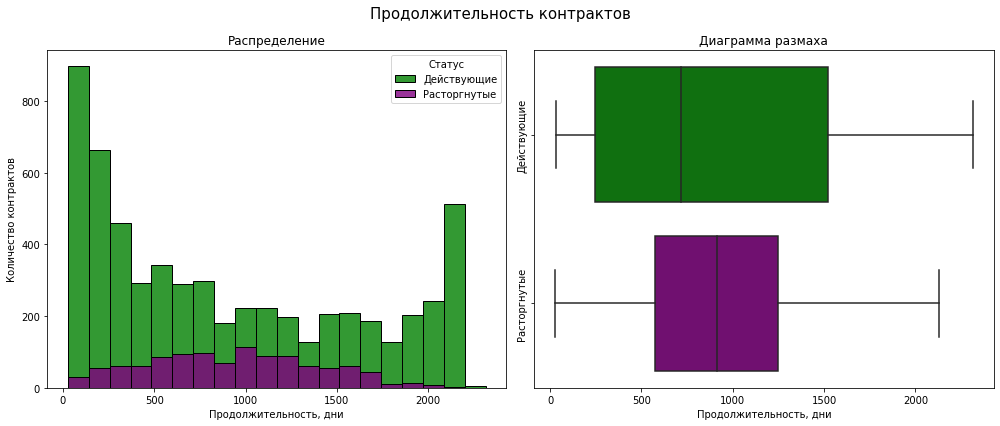

In [80]:
hist_box(
    data=df_clean, 
    x='duration_days', 
    title='Продолжительность контрактов', 
    xlabel='Продолжительность, дни'
)

In [81]:
# Действующие договоры
df_clean.query('is_ended == 0')['duration_days'].describe()

count    5890.000000
mean      898.811375
std       715.266107
min        31.000000
25%       245.000000
50%       716.000000
75%      1523.000000
max      2314.000000
Name: duration_days, dtype: float64

In [82]:
# Расторгнутые договоры
df_clean.query('is_ended == 1')['duration_days'].describe()

count    1101.000000
mean      924.863760
std       458.771309
min        28.000000
25%       577.000000
50%       915.000000
75%      1249.000000
max      2129.000000
Name: duration_days, dtype: float64

Действующие контракты:
- в выборке представлены значения от 31 до 2314 дней, продолжительность большинства контрактов находится в диапазоне от 245 до 1523 дней;
- среднее и медианное значения существенно отличаются (898.8 и 716 дней), это говорит об асимметричности данных и смещении влево;
- распределение бимодальное: один пик в области коротких контрактов (до 100 дней), второй — в области длительных (2100 и более);
- аномалий и выбросов нет.

Расторгнутые контракты:
- в выборке представлены значения от 28 до 2129 дней, продолжительность большинства контрактов находится в диапазоне от 577 до 1249 дней;
- среднее и медианное значения отличаются незначительно (924.9 и 915 дней), это говорит о симметричности данных и  небольшом смещении влево;
- распределение близко к нормальному, наиболее частые значения в районе 1000 дней;
- аномалий и выбросов нет.

Левое смещение обоих распределений говорит о преобладании коротких контрактов, в случае с действующими более ярко выраженном.
Чаще других расторгаются контракты средней продолжительности (около 1000 дней), более длительные или недавно начавшиеся контракты расторгаются реже.

Выводы для подготовки данных и модели:\
Признак duration_days хорошо разделяет классы и имеет прогностическую ценность.\
Выбросы отсутствуют, очистка данных не требуется.\
При использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию. Для моделей-бустингов и деревьев масштабирование не требуется.

#### Ежемесячные платежи

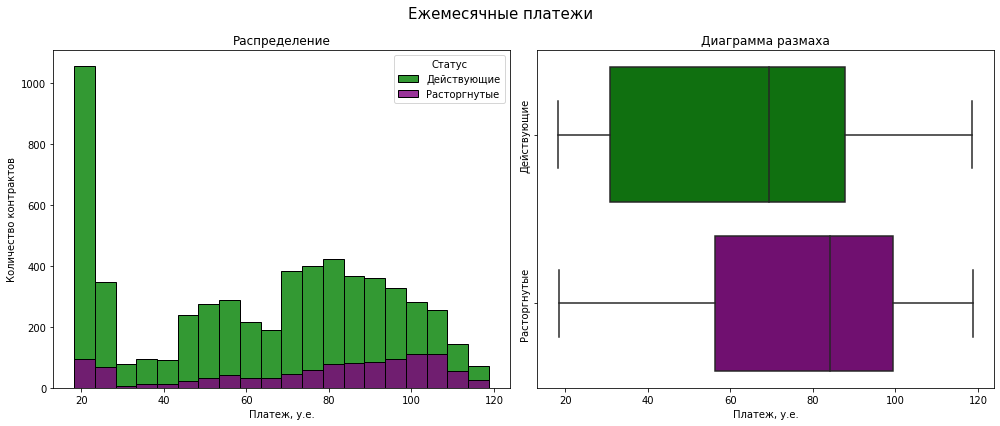

In [83]:
hist_box(
    data=df_clean, 
    x='monthly_charges', 
    title='Ежемесячные платежи', 
    xlabel='Платеж, у.е.'
)

In [84]:
# Действующие договоры
df_clean.query('is_ended == 0')['monthly_charges'].describe()

count    5890.000000
mean       63.038098
std        29.758923
min        18.250000
25%        30.925000
50%        69.400000
75%        87.787500
max       118.600000
Name: monthly_charges, dtype: float64

In [85]:
# Расторгнутые договоры
df_clean.query('is_ended == 1')['monthly_charges'].describe()

count    1101.000000
mean       75.546004
std        29.116213
min        18.400000
25%        56.150000
50%        84.200000
75%        99.500000
max       118.750000
Name: monthly_charges, dtype: float64

Действующие контракты:
- в выборке представлены значения от 18.3 до 118.6 у.е., большинство значений находятся в диапазоне от 30.9 до 87.8 у.е.;
- среднее и медианное значения отличаются незначительно (63 и 69.4 у.е.), это говорит о небольшом смещении вправо и о том, что сильной асимметрии в данных нет;
- распределение мультимодальное: наибольший пик в области низких значений (20 у.е.), два пика поменьше заметны в районе 50 и 80 у.е.;
- аномалий и выбросов нет.

Расторгнутые контракты:
- в выборке представлены значения от от 18.4 до 118.8 у.е., большинство значений находятся в диапазоне от 56.2 до 99.5 у.е.;
- среднее и медианное значения отличаются незначительно (75.5 и 84.2 у.е.), это говорит о небольшом смещении вправо и о том, что сильной асимметрии в данных нет;
- распределение бимодальное: один пик в области низких значений (20 у.е.), второй — в области высоких (100-110 у.е.);
- аномалий и выбросов нет.

Чаще других расторгаются контракты с низкими (20 у.е.) и высокими ежемесячными платежами (100-110 у.е.). Бимодальность отражает две разные группы расторгающих: клиенты с минимальными пакетами и клиенты с максимальной нагрузкой.
Средний ежемесячный платеж по действующим контрактам (63 у.е.) ниже, чем по расторгнутым (75.5 у.е.) на 16.6%. 

Выводы для подготовки данных и модели:\
Признак monthly_charges имеет потенциальную прогностическую ценность.\
Выбросы отсутствуют, очистка данных не требуется.\
При использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию. Для моделей-бустингов и деревьев масштабирование не требуется.

### Исследовательский анализ порядкового признака "количество подключенных интернет-услуг"

In [86]:
def get_table(data, cat_col, target_col='is_ended'):
    """
    Формирует сводную таблицу с количеством контрактов по категориям
    и рассчитывает долю оттока.

    Args:
        data (pd.DataFrame): Входной датасет.
        cat_col (str): Название категориального признака для группировки.
        target_col (str, optional): Название целевой переменной,
            отражающей статус контракта. По умолчанию 'is_ended'.

    Returns:
        pd.DataFrame: Сводная таблица с количеством контрактов,
        общим числом и процентом оттока по категориям.
    """
    # Сводная таблица с количеством контрактов по статусам
    tbl = data.pivot_table(
        index=cat_col,
        columns=target_col,
        aggfunc='size'
    ).rename(columns={0: 'Действующие', 1: 'Расторгнутые'})
    
    # Расчет общего количества контрактов
    tbl['Всего'] = tbl['Действующие'] + tbl['Расторгнутые']

    # Сортировка по общему количеству
    tbl = tbl.sort_values('Всего', ascending=False)
    
    # Расчет доли расторгнутых контрактов
    tbl['Отток, %'] = round((tbl['Расторгнутые'] / tbl['Всего']) * 100, 1)
    
    return tbl

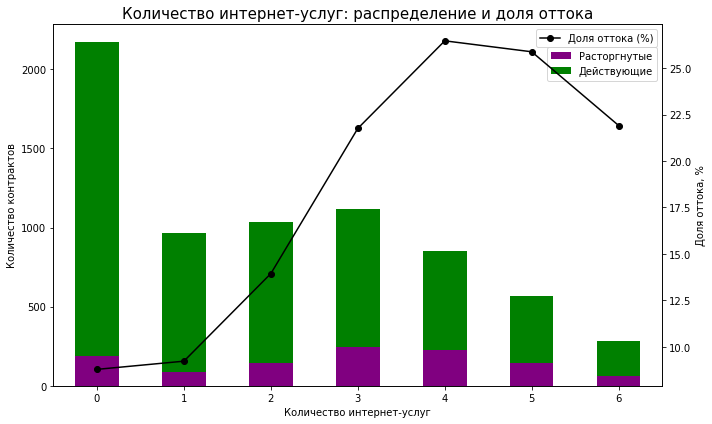

In [87]:
# Визуализация распределения контрактов по количеству интернет-услуг
fig, ax1 = plt.subplots(figsize=(10, 6))

# Построение агрегированной таблицы по статусу контрактов
table = (df_clean.pivot_table(
    index='serv_number', columns='is_ended', aggfunc='size')
)
# Изменение порядка столбцов для корректного отображения легенды
table = table[[1, 0]]

# Столбчатая диаграмма с накоплением по статусам контрактов
table.plot.bar(stacked=True, color=['purple', 'green'], ax=ax1)

ax1.set_xlabel('Количество интернет-услуг')
ax1.set_ylabel('Количество контрактов')
ax1.legend(labels=['Расторгнутые', 'Действующие'], loc='upper right', bbox_to_anchor=(1, 0.95))
ax1.tick_params(axis='x', labelrotation=0)

# Создание второй оси для отображения доли оттока
ax2 = ax1.twinx()

# Расчет процента расторгнутых контрактов
churn_rate = table[1] / table.sum(axis=1) * 100

# Линейный график доли оттока
ax2.plot(
    table.index,
    churn_rate,
    marker='o',
    color='black',
    label='Доля оттока (%)'
)

ax2.set_ylabel('Доля оттока, %')
ax2.legend(loc='upper right')

# Настройка заголовка и отступов фигуры
plt.title('Количество интернет-услуг: распределение и доля оттока', fontsize=15)
plt.tight_layout()
plt.show()

In [88]:
# Количество контрактов по категориям
get_table(df_clean, cat_col='serv_number', target_col='is_ended')

is_ended,Действующие,Расторгнутые,Всего,"Отток, %"
serv_number,,,,
0,1984,191,2175,8.8
3,874,243,1117,21.8
2,889,144,1033,13.9
1,876,89,965,9.2
4,625,225,850,26.5
5,421,147,568,25.9
6,221,62,283,21.9


В выборке представлены значения от 0 до 6 подключенных интернет-услуг. Распределение несимметрично и смещено в сторону меньших значений. По действующим контрактам распределение похоже на общее по всей выборке, а по расторгнутым можно выделить два пика — 0 и 3-4 контракта: 
- 0 услуг — самая крупная группа: 2175 контрактов, из них 1984 действующих и 191 расторгнутый;
- 3 услуги — 1117 контрактов (874 действующих, 243 расторгнутых);
- 2 услуги — 1033 контракта (889 действующих, 144 расторгнутых);
- 1 услуга — 965 контрактов (876 действующих, 89 расторгнутых);
- 4 услуги — 850 контрактов (625 действующих, 225 расторгнутых);
- 5 услуг — 568 контрактов (421 действующий, 147 расторгнутых);
- 6 услуг — самая маленькая группа: 283 контракта (221 действующий, 62 расторгнутых).

Доля оттока растет при увеличении количества подключенных услуг:
- 0 услуг — 8.8%
- 1 услуга — 9.2%
- 2 услуги — 13.9%
- 3 услуги — 21.8%
- 4 услуги — 26.5%
- 5 услуг — 25.9%
- 6 услуг — 21.9%

Максимальные значения оттока наблюдаются у клиентов с 4 (26.5%) и 5 услугами (25.9%).

Выводы для моделирования:\
Признак демонстрирует явную зависимость от целевой переменной (доля оттока увеличивается по мере роста количества услуг), это делает его информативным для модели.\
При использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию. Для моделей-бустингов и деревьев масштабирование не требуется.

### Исследовательский анализ категориальных  признаков

In [89]:
def count_and_pies(data, cat_col, hue_col='is_ended'):
    """
    Визуализирует распределение категориального или порядкового признака с помощью
    столбчатой диаграммы и круговых диаграмм по каждой категории.

    Args:
        data (pd.DataFrame): Входной датасет.
        cat_col (str): Название категориального или порядкового признака.
        hue_col (str, optional): Название переменной, отражающей статус
            объектов. По умолчанию 'is_ended'.

    Returns:
        None
    """
    
    # Формирование агрегированной таблицы распределений
    table = data.pivot_table(
        index=cat_col,
        columns=hue_col,
        aggfunc='size'
    ).assign(
        total=lambda x: x.sum(axis=1)
    ).sort_values(
        'total', ascending=False
    ).drop(columns='total')

    # Получение списка категорий, отсортированных по убыванию частоты
    cat_order = data[cat_col].value_counts().index.tolist()
    
    # Определение количества уникальных категорий
    n_cats = len(cat_order)

    # Настройка схемы расположения графиков
    if n_cats <= 2:
        layout = [['bar', 'pie1', 'pie2']]
        figsize = (14, 5)
    else:
        layout = [['bar', 'pie1', 'pie2'],
                  ['bar', 'pie3', 'pie4']]
        figsize = (14, 7)

    # Создание набора осей с использованием мозаичной схемы
    fig, axes = plt.subplot_mosaic(layout, figsize=figsize)
    
    # Столбчатая диаграмма распределения категорий
    table.plot.bar(stacked=True, color=['green', 'purple'], ax=axes['bar'])
     
    axes['bar'].set_title(f'Распределение по {cat_col}')
    axes['bar'].set_xlabel('')
    axes['bar'].set_ylabel('Количество клиентов')
    axes['bar'].legend(title='Статус', labels=['Действующие', 'Расторгнутые'])
    axes['bar'].tick_params(axis='x', rotation=20)

    # Круговые диаграммы по каждой категории
    for i, cat in enumerate(cat_order[:n_cats], start=1):
        axes[f'pie{i}'].pie(
            table.loc[cat].values, 
            labels=['Действующие', 'Расторгнутые'],
            autopct='%1.1f%%',
            colors=['green', 'purple'],
            startangle=90
        )
        axes[f'pie{i}'].set_title(str(cat), fontsize=11)

    # Отключение неиспользуемых осей (если категорий < 4)
    for j in range(n_cats + 1, 7):
        ax_name = f'pie{j}'
        if ax_name in axes:
            axes[ax_name].axis('off')

    # Настройка заголовка и отступов фигуры
    fig.suptitle(f'Анализ признака "{cat_col}"', fontsize=15)
    plt.tight_layout()
    plt.show()

#### Тип контракта

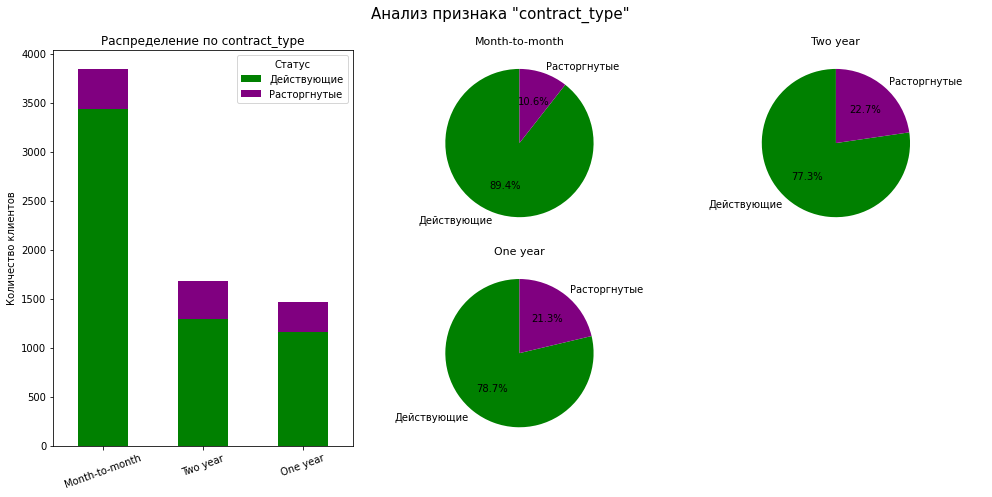

In [90]:
count_and_pies(data=df_clean, cat_col='contract_type', hue_col='is_ended')

In [91]:
# Количество контрактов по категориям
get_table(df_clean, cat_col='contract_type', target_col='is_ended')

is_ended,Действующие,Расторгнутые,Всего,"Отток, %"
contract_type,,,,
Month-to-month,3435,407,3842,10.6
Two year,1298,381,1679,22.7
One year,1157,313,1470,21.3


Наиболее распространённый тип контракта — "Month-to-month" (всего 3842, в т.ч. действующих 3435, расторгнутых 407).
На втором месте — двухгодичные контракты (всего 1679, в т.ч. действующих 1298, расторгнутых 381), на третьем — контракты длительностью один год (всего 1470, в т.ч. действующих 1157, расторгнутых 313).

Чем длиннее контракт, тем меньше клиентов, но доля расторгнутых выше: контракты на 1 и 2 года имеют сопоставимые доли оттока (21.3% и 22.7%) против 10.6% среди контрактов на 1 месяц. Однако в абсолютных числах большинство оттоков всё равно приходится на Month-to-month, потому что таких клиентов значительно больше.

Выводы для подготовки данных и модели:\
Признак contract_type имеет потенциальную прогностическую ценность.\
Для подготовки данных необходимо использовать OneHotEncoder.

#### Тип счета

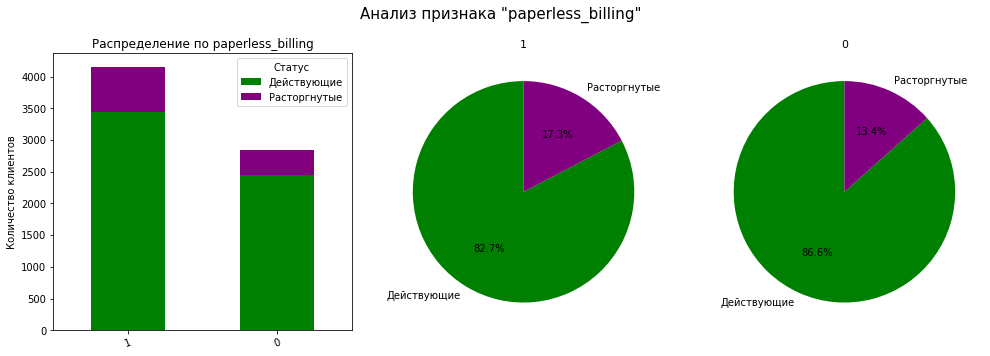

In [92]:
count_and_pies(data=df_clean, cat_col='paperless_billing', hue_col='is_ended')

In [93]:
# Количество контрактов по категориям
get_table(df_clean, cat_col='paperless_billing', target_col='is_ended')

is_ended,Действующие,Расторгнутые,Всего,"Отток, %"
paperless_billing,,,,
1,3436,721,4157,17.3
0,2454,380,2834,13.4


Наиболее многочисленная группа — клиенты с электронным биллингом: всего 4157 контракта, из них 3436 действующих и 721 расторгнутых.
Группа клиентов без электронного биллинга заметно меньше — 2834 контракта, из них 2454 действующих, 380 расторгнутых.

Доля расторгнутых контрактов среди клиентов с электронным биллингом немного больше, чем в другой группе (17.3% и 13.4% соответственно).

Это означает, что клиенты с paperless_billing демонстрируют немного более высокий риск оттока. Это может отражать особенности клиентского поведения: пользователи, активно взаимодействующие онлайн, легче меняют поставщика услуг и быстрее реагируют на предложения конкурентов.

Выводы для подготовки данных и модели:\
Признак contract_type имеет потенциальную прогностическую ценность.\
Так как признак бинарный, его можно использовать в модели напрямую, подготовка данных не требуется.

#### Метод оплаты

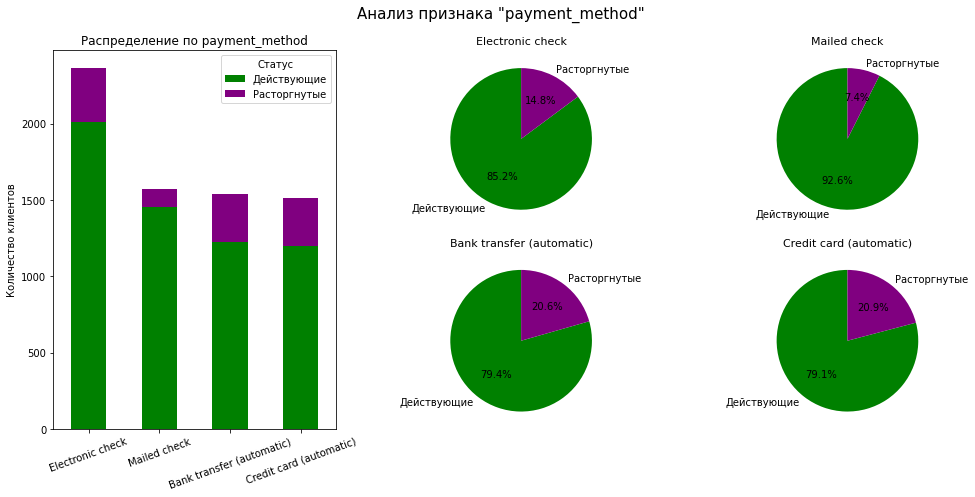

In [94]:
count_and_pies(data=df_clean, cat_col='payment_method', hue_col='is_ended')

In [95]:
# Количество контрактов по категориям
get_table(df_clean, cat_col='payment_method', target_col='is_ended')

is_ended,Действующие,Расторгнутые,Всего,"Отток, %"
payment_method,,,,
Electronic check,2012,350,2362,14.8
Mailed check,1454,117,1571,7.4
Bank transfer (automatic),1224,317,1541,20.6
Credit card (automatic),1200,317,1517,20.9


Наиболее многочисленная группа — Electronic check: всего 2362 контракта, из них действующих 2012 и расторгнутых 350. На втором месте по численности — Mailed check с 1571 контрактом (действующих 1454, расторгнутых 117). Две группы с автоматической формой оплаты — Bank transfer (automatic) и Credit card (automatic) — имеют сравнимые размеры: 1541 (1224 действующих, 317 расторгнутых) и 1517 (1200 действующих, 317 расторгнутых) контрактов соответственно.

Доли оттока заметно различаются: Mailed check показывает наименьшую долю оттока — всего 7.4%, Electronic check — 14.8%, Bank transfer (automatic) — 20.6%, Credit card (automatic) — 20.9%.

Таким образом, клиенты, оплачивающие банковским переводом или автосписанием с карты, более склонны к оттоку, чем другие группы. Наименее "рисковыми" являются клиенты, использующие бумажные чеки — это может отражать их более консервативное поведение и склонность оставаться с текущим провайдером.

Выводы для подготовки данных и модели:\
Признак payment_method демонстрирует существенные различия в долях оттока и обладает прогностической ценностью.\
Это категориальный признак с четырьмя уникальными значениями — необходимо применить OneHotEncoder перед обучением модели.

#### Характеристики телефонного подключения

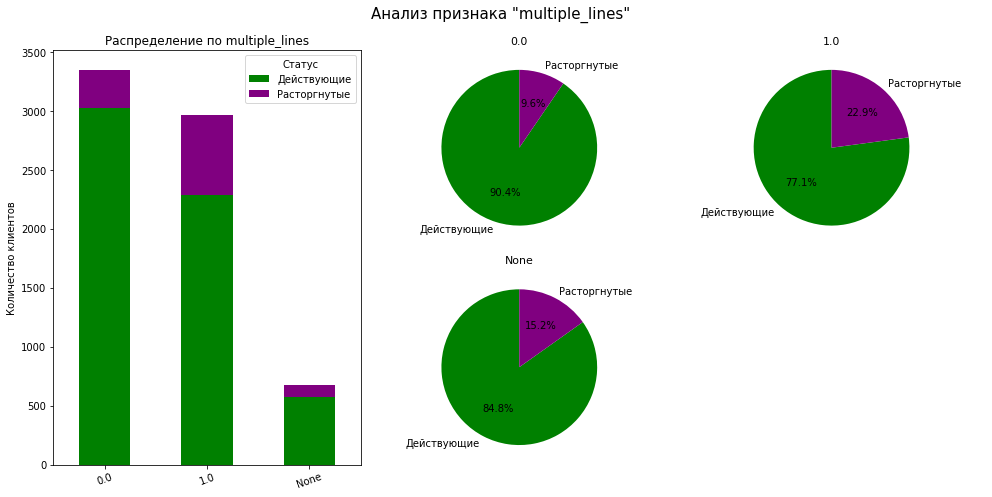

In [96]:
count_and_pies(data=df_clean, cat_col='multiple_lines', hue_col='is_ended')

In [97]:
# Количество контрактов по категориям
get_table(df_clean, cat_col='multiple_lines', target_col='is_ended')

is_ended,Действующие,Расторгнутые,Всего,"Отток, %"
multiple_lines,,,,
0.0,3028,320,3348,9.6
1.0,2286,678,2964,22.9
None,576,103,679,15.2


Признак показывает, подключена ли у клиента услуга нескольких телефонных линий. В данных представлены три значения: да (1), нет (0) и None (вообще не подключена услуга телефонии).

У большинства клиентов подключен телефон с одной линией: 3348 контрактов, из них 3028 действующих и 320 расторгнутых. Доля оттока — 9.6% (минимальная среди всех групп).

На втором месте группа с подключенной услугой нескольких телефонных линий: 2964 контракта, 2286 действующих и 678 расторгнутых. Доля оттока — 22.9% (максимальная среди всех групп).

None — наименьшая категория: 679 контрактов, 576 действующих и 103 расторгнутых. Доля оттока — 15.2%.


Выводы для подготовки данных и модели:\
Признак multiple_lines хорошо разделяет клиентов по риску оттока.\
Для подготовки данных необходимо использовать OneHotEncoder.

#### Личные данные клиентов

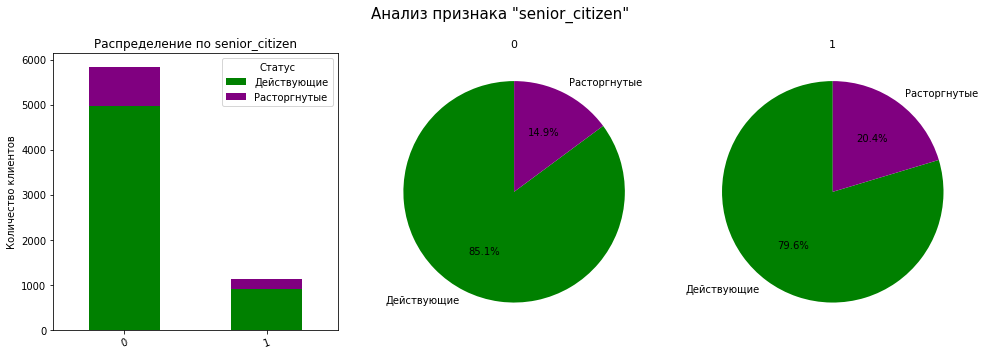

In [98]:
count_and_pies(data=df_clean, cat_col='senior_citizen', hue_col='is_ended')

In [99]:
# Количество контрактов по категориям
get_table(df_clean, cat_col='senior_citizen', target_col='is_ended')

is_ended,Действующие,Расторгнутые,Всего,"Отток, %"
senior_citizen,,,,
0,4982,869,5851,14.9
1,908,232,1140,20.4


Признак показывает, старше ли клиент 65 лет (1 — да, 0 — нет).

Большая часть клиентов относится к категории "до 65": 5851 контракт, из них 4982 действующих и 869 расторгнутых.
Категории "65+" гораздо менее многочисленная, к ней относятся 1140 контрактов, из них 908 действующих и 232 расторгнутых.

Пожилые клиенты уходят значительно чаще: 20.4% против 14.9% среди непожилых. Таким образом, вероятность оттока у пожилых клиентов выше примерно в 1.37 раза.

Выводы для подготовки данных и модели:\
Признак senior_citizen имеет выраженную связь с целевой переменной: пожилые клиенты демонстрируют более высокий риск оттока.\
Так как признак бинарный, его можно использовать в модели напрямую, подготовка данных не требуется.

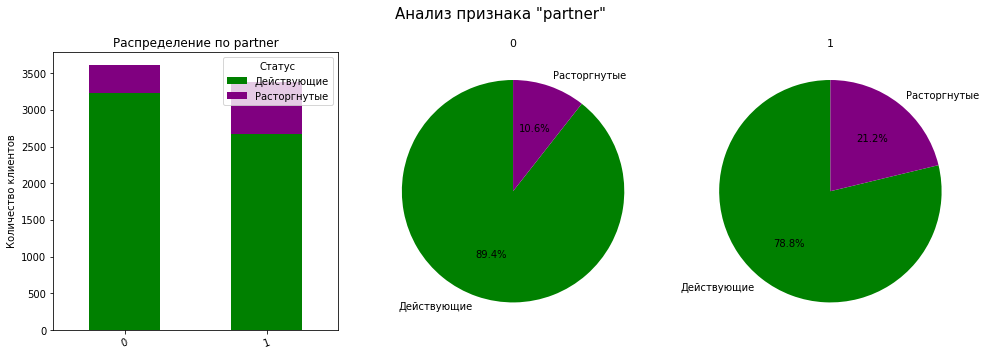

In [100]:
count_and_pies(data=df_clean, cat_col='partner', hue_col='is_ended')

In [101]:
# Количество контрактов по категориям
get_table(df_clean, cat_col='partner', target_col='is_ended')

is_ended,Действующие,Расторгнутые,Всего,"Отток, %"
partner,,,,
0,3223,382,3605,10.6
1,2667,719,3386,21.2


Признак показывает, есть ли у клиента есть ли у абонента супруг или супруга (1 — да, 0 — нет).

Большая часть клиентов не имеет партнера: 3605 контрактов, из них 3223 действующих и 382 расторгнутых. Категория клиентов с партнером немного меньше — 3386 контрактов, из них 2667 действующих и 719 расторгнутых.

Клиенты, состоящие в браке, демонстрируют значительно более высокий уровень оттока: 21.2% против 10.6% среди клиентов без партнера. Таким образом, вероятность оттока у клиентов с партнером примерно в 2 раза выше.

Выводы для подготовки данных и модели:\
Признак partner имеет выраженную связь с целевой переменной: клиенты в партнёрских отношениях уходят заметно чаще.\
Признак бинарный, его можно использовать в модели напрямую — дополнительная подготовка не требуется.

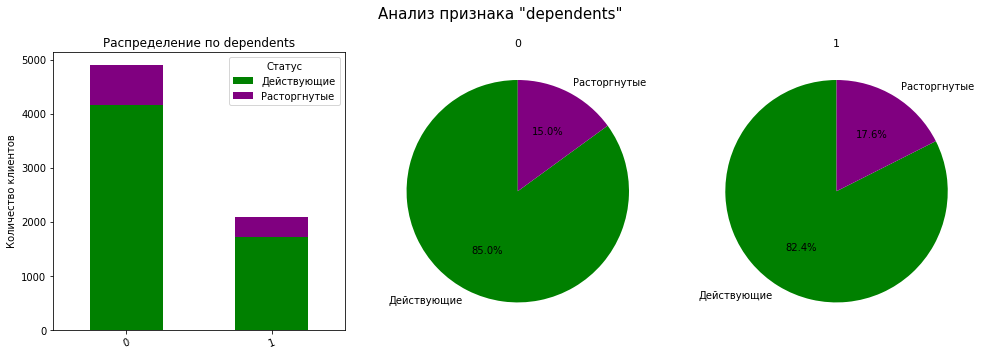

In [102]:
count_and_pies(data=df_clean, cat_col='dependents', hue_col='is_ended')

In [103]:
# Количество контрактов по категориям
get_table(df_clean, cat_col='dependents', target_col='is_ended')

is_ended,Действующие,Расторгнутые,Всего,"Отток, %"
dependents,,,,
0,4163,733,4896,15.0
1,1727,368,2095,17.6


Признак показывает, есть ли у клиента дети (1 — да, 0 — нет).

Большая часть клиентов не имеет детей: 4896 контрактов, из них 4163 действующих и 733 расторгнутых. Категория клиентов с детьми меньше — 2095 контрактов, из них 1727 действующих и 368 расторгнутых.

Клиенты с детьми демонстрируют несколько более высокий уровень оттока: 17.6% против 15.0% среди клиентов без детей. Таким образом, вероятность ухода у клиентов с детьми примерно в 1.17 раза выше.

Выводы для подготовки данных и модели:\
Признак dependents имеет умеренную связь с целевой переменной: наличие днтей слабо, но все же повышает риск оттока.\
Признак бинарный, поэтому его можно использовать напрямую, дополнительная подготовка не требуется.

### Вывод по разделу

На данном этапе мы провели корреляционный и исследовательский анализ и сделали выводы относительно полезности признаков для модели и необходимых методов подготовки данных.

Ряд признаков необходимо удалить для исключения дублирования, мультиколлинеарности, утечки данных и в связи с неинформативностью:
- end_date полностью повторяет целевой показатель (Фи-к = 1.0) и создает прямую утечку данных;
- begin_date мультиколлинеарен признаку duration_days (Фи-к = 0.98) и является псевдопризнаком — он не отражает поведение клиента, его удаление также предотвращает переобучение на конкретную дату выгрузки данных;
- total_charges 
- gender связь с целевым признаком практически отсутствует (Фи-к = 0.009);
- internet_service мультиколлинеарен признаку monthly_charges (Фи-к = 0.92) и имеет очень слабую связь с целевым (Фи-к = 0.056);
- online_security, online_backup, device_protection, tech_support, streaming_tv и streaming_movies: для снижения избыточности оставим агрегированный единый признак serv_number (количество подключенных услуг).

Наиболее значимые признаки для прогноза оттока клиентов: 
1. duration_days:
- имеет умеренную связь с целевым (Фи-к = 0.37); 
- действующие и расторгнутые контракты имеют различные распределения, максимальный отток наблюдается у контрактов средней длительности (около 1000 дней) — признак хорошо разделяет классы и имеет прогностическую ценность;
- выбросы отсутствуют, очистка данных не требуется; при использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию; для моделей-бустингов и деревьев масштабирование не требуется.
2. monthly_charges:
- имеет слабую связь с целевым (Фи-к = 0.23);
- действующие и расторгнутые контракты имеют различные распределения, но можно заметить, что отток максимален среди самых дешевых (20 у.е.) и самых дорогих тарифов (100-110 у.е.) и что средний ежемесячный платеж по действующим контрактам (63 у.е.) ниже, чем по расторгнутым (75.5 у.е.) на 16.6% — признак имеет потенциальную прогностическую ценность;
- выбросы отсутствуют, очистка данных не требуется; при использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию; для моделей-бустингов и деревьев масштабирование не требуется.
3. partner:
- имеет слабую связь с целевым (Фи-к = 0.23);
- клиенты, состоящие в браке, расторгают контракт почти вдвое чаще (21.2% против 10.6%) — признак хорошо разделяет классы и имеет прогностическую ценность;
- признак бинарный, его можно использовать в модели напрямую — подготовка данных не требуется.
4. payment_method:
- имеет слабую связь с целевым (Фи-к = 0.21);
- доли оттока по категориям заметно различаются: Mailed check — 7.4%, Electronic check — 14.8%, Bank transfer (automatic) — 20.6%, Credit card (automatic) — 20.9%. Клиенты, оплачивающие банковским переводом или автосписанием с карты, более склонны к оттоку, чем другие группы — признак имеет прогностическую ценность;
- это категориальный признак с четырьмя уникальными значениями — необходимо применить OneHotEncoder перед обучением модели.
5. serv_number:
- имеет слабую связь с целевым (Фи-к = 0.18);
- доля оттока растет при увеличении количества подключенных услуг (0 — 8.8%, 1 — 9.2%, 2 — 13.9%, 3 — 21.8%, 4 — 26.5%, 5 — 25.9%, 6 — 21.9%) — признак имеет прогностическую ценность;
- при использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию; для моделей-бустингов и деревьев масштабирование не требуется.
6. multiple_lines:
- имеет слабую связь с целевым (Фи-к = 0.11);
- минимальная доля оттока у клиентов с одной линией (9.6%), на втором месте клиенты, у которых не подключена услуга телефонии (15.2%), максимальная у клиентов с несколькими телефонными линиями (22.9%) — признак хорошо разделяет клиентов по риску оттока и имеет прогностическую ценность;
- это категориальный признак с тремя уникальными значениями — необходимо применить OneHotEncoder перед обучением модели.


Прочие признаки имеют слабую, но значимую связь с целевым. Их не стоит удалять, потому что они могут вносить вклад в предсказание в сочетании с другими:
- признаки контрактов contract_type (Фи-к = 0.095) и paperless_billing (Фи-к = 0.083): чем длиннее контракт, тем выше доля расторгнутых (контракты на 1 и 2 года имеют сопоставимые доли оттока (21.3% и 22.7%) против 10.6% среди контрактов на 1 месяц), доля расторгнутых контрактов среди клиентов с электронным биллингом немного больше, чем в другой группе (17.3% и 13.4% соответственно);
- персональные признаки senior_citizen (Фи-к = 0.086) и dependents (Фи-к = 0.049): пожилые клиенты уходят чаще (20.4% против 14.9%), клиенты с детьми — немного чаще остальных (17.6% против 15.0%).

Все эти признаки бинарные, подготовка данных не требуется.

После удаления признаков, мы проверили датасет на наличие дубликатов. В датасете появилась 41 строка, в которой дублируются все значения, кроме id. Ценности для модели такие строки не имеют, поэтому мы их удалили.

В результате сформирован оптимальный набор признаков: удалены переменные с утечкой, мультиколлинеарностью или отсутствием прогностической ценности, оставлены те, которые дают различимые сигналы риска оттока и способны улучшить качество модели.

## Подготовка данных и обучение моделей

### Подготовка данных

Сохраним целевой и входные признаки в разные переменные.

In [104]:
X = df_clean.drop('is_ended', axis=1)
y = df_clean['is_ended']

В качестве метрики качества используется ROC-AUC, устойчивая к дисбалансу классов. В связи с этим стратифицированное разбиение выборки не применяется.

In [105]:
# Фиксация генератора случайных чисел
RANDOM_STATE = 171125

In [106]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE)

Разделим признаки по типам для последующей обработки.

In [107]:
# Категориальные признаки
cat_columns = [
    'contract_type',
    'payment_method',
    'multiple_lines'
]

# Бинарные признаки
bin_columns = [
    'paperless_billing',
    'senior_citizen',
    'partner',
    'dependents'
]

# Числовые признаки
num_columns = [
    'monthly_charges', 
    'duration_days', 
    'serv_number'
]              

Для кодирования категориальных признаков используем One-Hot Encoding.

In [108]:
# Пайплайн кодирования категориальных признаков
ohe_pipe = Pipeline([
    (
        'ohe', OneHotEncoder(
            drop='first', 
            sparse_output=False, 
            handle_unknown='ignore'
        )
    )
])

In [109]:
# Комплексная предобработка признаков
preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, cat_columns),
    ('bin', 'passthrough', bin_columns),
    ('num', StandardScaler(), num_columns)
])

В качестве базовой используем модель логистической регрессии.

In [110]:
# Итоговый пайплайн предобработки и обучения модели
basic_pipe = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model', 
        LogisticRegression(
            random_state=RANDOM_STATE, 
            max_iter=5000
        )
    )
]) 

### LogisticRegression

Выполним подбор гиперпараметров модели логистической регрессии с использованием случайного поиска.

In [111]:
# Пространство гиперпараметров модели
lr_grid = [
    {
        'model__solver': ['saga', 'liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.5, 0.1, 0.5, 1]
    }
]

In [112]:
# Поиск оптимальных гиперпараметров
lr_search = RandomizedSearchCV(
    basic_pipe, 
    param_distributions=lr_grid, 
    cv=3,
    n_iter=20,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [114]:
# Обучение моделей
lr_search.fit(X_train, y_train)

print("Лучшие параметры модели:")
print(lr_search.best_params_)

print(f"\nПоказатель ROC-AUC: {round(lr_search.best_score_, 4)}")

print(f"\nВремя обучения лучшей модели: {round(lr_search.refit_time_, 2)} сек.")

Лучшие параметры модели:
{'model__solver': 'saga', 'model__penalty': 'l1', 'model__C': 0.1}

Показатель ROC-AUC: 0.7377

Время обучения лучшей модели: 0.14 сек.


Метрика качества не достигает требуемого порога, поэтому модель логистической регрессии не может быть выбрана в качестве финальной.

### RandomForest

Выполним подбор гиперпараметров модели случайного леса.

In [115]:
# Пространство гиперпараметров модели
rf_grid = [
    {
        'model': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'model__n_estimators': [300, 350, 400],
        'model__max_depth': [5, 7, 10],
        'model__min_samples_split': [2, 3, 4],
        'model__min_samples_leaf': [3, 5, 7],
        'preprocessor__num': ['passthrough']
    }
]

In [116]:
# Поиск оптимальных гиперпараметров
rf_search = RandomizedSearchCV(
    basic_pipe, 
    param_distributions=rf_grid, 
    cv=3,
    n_iter=20,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [117]:
# Обучение моделей
rf_search.fit(X_train, y_train)

print("Лучшие параметры модели:")
print(rf_search.best_params_)

print(f"\nПоказатель ROC-AUC: {round(rf_search.best_score_, 4)}")

print(f"\nВремя обучения лучшей модели: {round(rf_search.refit_time_, 2)} сек.")

Лучшие параметры модели:
{'preprocessor__num': 'passthrough', 'model__n_estimators': 350, 'model__min_samples_split': 4, 'model__min_samples_leaf': 7, 'model__max_depth': 7, 'model': RandomForestClassifier(random_state=171125)}

Показатель ROC-AUC: 0.8197

Время обучения лучшей модели: 1.29 сек.


Модель демонстрирует существенное улучшение качества по сравнению с логистической регрессией, однако не достигает требуемого порога метрики.

### CatBoost

CatBoostClassifier может работать с сырыми категориальными признаками, поэтому для данной модели мы не будем использовать пайплайн с препроцессингом — это упростит последующую интерпретацию модели.

In [118]:
# Инициализация модели с указанием категориальных признаков
cb_model = CatBoostClassifier(
    cat_features=cat_columns,
    verbose=False, 
    random_state=RANDOM_STATE
)

In [119]:
# Пространство гиперпараметров модели
cb_grid = {
    'iterations': [500, 1000],
    'depth': [3, 4, 5],
    'learning_rate': [0.1, 0.15, 0.2, 0.25],
    'l2_leaf_reg': [1, 2],
    'loss_function': ['Logloss', 'CrossEntropy'],
    'border_count': [100, 300]
}

In [120]:
# Поиск оптимальных гиперпараметров
cb_search = RandomizedSearchCV(
    estimator=cb_model,
    param_distributions=cb_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [121]:
# Обучение моделей
cb_search.fit(X_train, y_train)

print("Лучшие параметры модели:")
print(cb_search.best_params_)

print(f"\nПоказатель ROC-AUC: {round(cb_search.best_score_, 4)}")

print(f"\nВремя обучения лучшей модели: {round(cb_search.refit_time_, 2)} сек.")

Лучшие параметры модели:
{'loss_function': 'Logloss', 'learning_rate': 0.25, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 3, 'border_count': 300}

Показатель ROC-AUC: 0.9182

Время обучения лучшей модели: 6.03 сек.


Метрика лучшей модели CatBoostClassifier на кросс-валидации — 0.9182, модель достигла требуемого порогового значения качества.

### Вывод по разделу 

На данном этапе мы настроили и обучили три модели для предсказания вероятности оттока клиентов: LogisticRegression, RandomForestRegressor и CatBoostClassifier.

Для моделей LogisticRegression и RandomForestRegressor категориальные признаки кодировались с помощью OneHotEncoder, модели CatBoostClassifier передавались в незакодированном виде. Количественные признаки подготавливались с помощью StandardScaler только для LogisticRegression, остальные модели не требуют стандартизации.

Для поиска наилучших гиперпараметров использовался инструмент RandomizedSearchCV.

Для LogisticRegression подбирались гиперпараметры: солвер, способ и сила регуляризации.\
Наилучший результат (ROC-AUC 0.7377 на кросс-валидации) показала модель с настройками: {'model__solver': 'saga', 'model__penalty': 'l1', 'model__C': 0.1}. Модель не достигла минимального значения метрики, требуемого в задаче (0.85).

Для RandomForest подбирались гиперпараметры: количество деревьев, глубина деревьев, минимальное кол-во образцов для разбиения и минимальное кол-во образцов в листе. \
Наилучший результат (ROC-AUC 0.8197 на кросс-валидации) показала модель с настройками: {'model__n_estimators': 350, 'model__max_depth': 7, 'model__min_samples_split': 4, 'model__min_samples_leaf': 7}. Метрика модели значительно превзошла LogisticRegression, но всё ещё не удовлетворяет условиям задачи.

Для CatBoostClassifier подбирались гиперпараметры: количество деревьев, глубина деревьев, скорость обучения, коэффициент L2-регуляризации, функция потерь и количество бинов для числовых признаков.\
Наилучший результат (ROC-AUC 0.9182 на кросс-валидации) показала модель с настройками: {'iterations': 1000, 'depth': 3, 'learning_rate': 0.25, 'l2_leaf_reg': 1, 'loss_function': 'Logloss', 'border_count': 300}.

Модель CatBoostClassifier достигла порогового значения качества.

## Выбор лучшей модели и интерпретация результатов

### Сравнение метрик и времени обучения

Сведём показатели качества и времени обучения моделей в единую таблицу.

In [122]:
results = pd.DataFrame({
    'ROC-AUC': [round(lr_search.best_score_, 4),
                round(rf_search.best_score_, 4),
                round(cb_search.best_score_, 4)
               ],
    'Время обучения (сек.)': [
                round(lr_search.refit_time_, 2), 
                round(rf_search.refit_time_, 2), 
                round(cb_search.refit_time_, 2)
                ]
}, index=['LogisticRegression', 'RandomForest', 'CatBoostClassifier'])
results = results.sort_values('ROC-AUC', ascending=False)
results

,ROC-AUC,Время обучения (сек.)
CatBoostClassifier,0.9182,6.03
RandomForest,0.8197,1.29
LogisticRegression,0.7377,0.14


Наилучший результат на кросс-валидации у модели CatBoostClassifier — ROC-AUC 0.9182. Лучшее время показала модель LogisticRegression, но она не достигла целевого значения метрики.

Проверим обобщающую способность лучшей модели на тестовой выборке.

In [123]:
# Лучшая обученная модель
best_model = cb_search.best_estimator_

In [124]:
# Расчет вероятностей положительного класса
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Оценка качества на тестовой выборке
print("ROC-AUC на тестовой выборке:", round(roc_auc_score(y_test, y_pred_proba), 4))

ROC-AUC на тестовой выборке: 0.9282


ROC-AUC на тестовой выборке составил 0.9282, что незначительно превышает результат кросс-валидации.
Близость метрик на обучающей и тестовой выборках свидетельствует о хорошей обобщающей способности модели и отсутствии переобучения.

Оценим качество классификации.

In [125]:
# Предсказание классов
preds = best_model.predict(X_test)

In [126]:
# Отчет о метриках классификации
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1449
           1       0.93      0.69      0.79       299

    accuracy                           0.94      1748
   macro avg       0.93      0.84      0.88      1748
weighted avg       0.94      0.94      0.93      1748



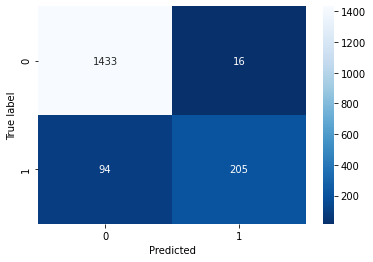

In [127]:
# Матрица ошибок классификации
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted')
plt.show()

Модель почти не допускает ошибок первого рода: ложноположительных результатов всего 16, что отражается в высоких значениях precision (0.94) и recall (0.99) по классу "0" (контракт не расторгнут).

Ошибок второго рода ощутимо больше: для класса "1" (контракт расторгнут) точность составляет 93%, в то время как полнота — только 69%, то есть модель в 31 случае из 100 дает ложноотрицательный результат.

Если бизнес-задача — минимизировать лишние затраты на удержание (ложные тревоги), текущая модель подходит.
Если же приоритет — удержать максимум уходящих клиентов, потребуется снизить порог классификации и уменьшить количество ошибок второго рода.

### Анализ важности признаков

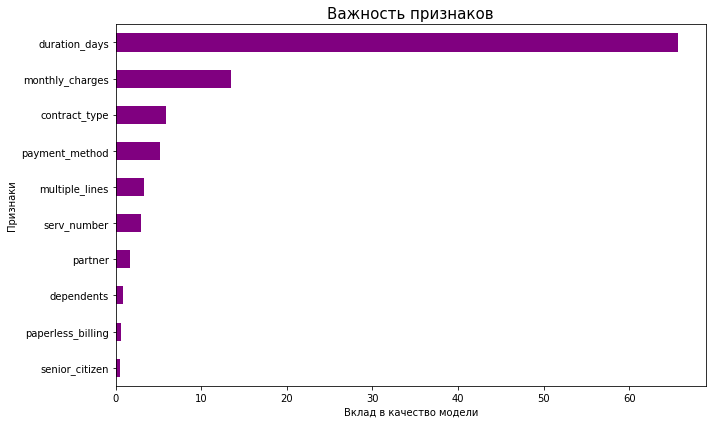

In [128]:
# Получение важности признаков обученной модели и визуализация
fi = best_model.get_feature_importance(prettified=True)
fi = pd.DataFrame(fi).set_index('Feature Id').sort_values(by='Importances')

fi['Importances'].plot.barh(figsize=(10, 6), color='purple')
plt.title('Важность признаков', fontsize=15)
plt.xlabel('Вклад в качество модели')
plt.ylabel('Признаки')
plt.legend().remove()
plt.tight_layout()
plt.show()

По результатам анализа важности признаков можно сделать следующие выводы:

1. Длительность обслуживания (duration_days) — ключевой фактор

Этот признак оказывает наибольшее совокупное влияние на предсказания модели. Чаще других расторгаются контракты средней продолжительности (около 1000 дней), более длительные или недавно начавшиеся контракты расторгаются реже.

2. Ежемесячные платежи (monthly_charges) — важный фактор ценообразования

Признак занимает вторую позицию по значимости. Повышенная стоимость услуг часто связана с более высоким риском оттока.

3. Тип контракта (contract_type)

Категория контракта существенно влияет на итоговые предсказания. Клиенты на помесячных планах обычно демонстрируют более высокий риск оттока по сравнению с клиентами на годовых и двухгодичных контрактах.

4. Метод оплаты (payment_method)

Метод оплаты оказывает умеренное влияние на решение модели. Клиенты, оплачивающие банковским переводом или автосписанием с карты, более склонны к оттоку, чем другие группы. Наименее "рисковыми" являются клиенты, использующие бумажные чеки — это может отражать их более консервативное поведение и склонность оставаться с текущим провайдером.

5. Дополнительные услуги (multiple_lines, serv_number)

Количество подключенных услуг также влияет на вероятность оттока. Эти признаки имеют заметную, но не доминирующую важность.

6. Демографические признаки — минимальная значимость

partner, dependents, paperless_billing, senior_citizen находятся в нижней части рейтинга важности.
Их влияние на итоговое решение модели значительно слабее по сравнению с поведенческими и тарифными параметрами.

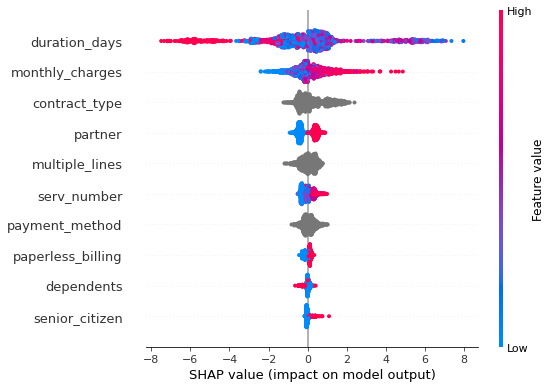

In [129]:
# Создание Pool для тестовой выборки
pool = Pool(X_test, y_test, cat_features=cat_columns)

# Получение SHAP-значений
shap_values = best_model.get_feature_importance(
    type='ShapValues',
    data=pool
)

# Удаление столбца с базовым значением предсказания
shap_values = shap_values[:, :-1]

# Визуализация важности признаков
shap.summary_plot(shap_values, X_test)

### Вывод по разделу

Наилучший результат на кросс-валидации у модели CatBoostClassifier — ROC-AUC 0.9182. Лучшее время показала модель LogisticRegression, но она не достигла целевого значения метрики.

На тестовой выборке модель CatBoostClassifier показала немного лучший результат, чем на кросс-валидации — ROC-AUC 0.9282. Метрики на тренировочной и тестовой выборках близки, что говорит о том, что модель устойчива на новых данных и не переобучилась.

Модель почти не допускает ошибок первого рода: ложноположительных результатов всего 16, что отражается в высоких значениях precision (0.94) и recall (0.99) по классу "0" (контракт не расторгнут).

Ошибок второго рода ощутимо больше: для класса "1" (контракт расторгнут) точность составляет 93%, в то время как полнота — только 69%, то есть модель в 31 случае из 100 дает ложноотрицательный результат.

Если бизнес-задача — минимизировать лишние затраты на удержание (ложные тревоги), текущая модель подходит.
Если же приоритет — удержать максимум уходящих клиентов, потребуется снизить порог классификации и уменьшить количество ошибок второго рода.

Интерпретация результатов проводилась методами Feature Importance и SHAP. Оба метода показывают согласующуюся картину: модель в первую очередь опирается на поведенческие и тарифные признаки, а не на демографию. Наибольшее влияние на предсказание оказывают три ключевых фактора: длительность обслуживания, ежемесячные платежи и тип контракта.

1. Длительность обслуживания (duration_days) является наиболее значимым признаком.
FI показывает, что этот параметр вносит наибольший вклад в модель, а SHAP подтверждает направление влияния: низкие  значения увеличивают вероятность оттока, большие значения снижают риск.

2. Ежемесячные платежи (monthly_charges) — второй по важности признак.
Высокие платежи смещают SHAP-значения вправо, увеличивая вероятность оттока; низкие — наоборот. Это согласуется с тем, что высокая стоимость услуг может быть причиной ухода клиентов.

3. Тип контракта (contract_type) заметно влияет на модель по FI: признак важен, однако SHAP не позволяет определить направление влияния конкретных категорий.

4. Признаки, связанные с использованием дополнительных услуг (serv_number, multiple_lines), и признак partner оказывают умеренное влияние.
SHAP показывает, что высокое количество услуг и наличие партнера чаще смещают предсказание в сторону оттока, хотя эффект слабее, чем у duration_days и monthly_charges.

5. Признак payment_method оказывает некоторое влияние: модель различает категории методов оплаты, хотя направление влияния не читается по SHAP-summary. Вклад умеренный.

6. Демографические признаки (senior_citizen, dependents, а также paperless_billing) имеют минимальную значимость — и по FI, и по SHAP. Модель почти не использует их при принятии решений.

## Общий вывод и рекомендации заказчику

**Загрузка, первичный осмотр и предобработка данных**

На данном этапе были загружены и изучены четыре исходных файла: contract_new.csv, personal_new.csv, internet_new.csv и phone_new.csv.

В ходе анализа:

- во всех таблицах столбцы переименованы в соответствии со стандартом PEP 8;
- подтверждено, что идентификаторы клиентов (customer_id) уникальны, пропусков нет;
- в датафрейме contract выполнено преобразование типов данных: даты приведены к формату datetime, расходы — к числовому типу float;
- создан бинарный целевой признак is_ended, отражающий факт расторжения договора, рассчитана продолжительность договора (duration_days);
- пропуски в end_date заменены датой актуальности выгрузки (1 февраля 2020 года);
- выявлено, что около 16% договоров были расторгнуты к указанной дате;
- пропуски в total_charges заменены нулями — они соответствуют договорам, заключенным в день выгрузки, по которым еще не было платежей;
- в остальных наборах данных проведена проверка типов и уникальных значений: все признаки корректны, неявных дубликатов и аномалий не выявлено.

Таким образом, данные успешно загружены и приведены к единому формату. Все таблицы готовы к объединению по ключу customer_id и дальнейшему исследовательскому анализу.

**Объединение таблиц и предобработка данных объединённого датафрейма**

На данном этапе мы объединили исходные датафреймы по индексам (customer_id) методом left join.

Итоговый датафрейм содержит 22 столбца и 7032 строк.

После объединения возникали пропуски в полях, относящихся к интернет- и телефонным услугам для клиентов без соответствующих подписок.

Проверка показала, что в датафрейме нет клиентов одновременно без интернета и без телефонии (0 строк с пропусками в обоих блоках).

В ходе обработки пропусков:
- в столбцах internet_service и multiple_lines заполнены заглушками 'None';
- в столбцах с признаками наличия подключенных интернет-услуги и их количеством заполнены 0 и приведены к int.

В результате пропусков нет, типы данных приведены к целевым (datetime для дат, float/int для числовых, object для категориальных, int для бинарных).

Датафрейм готов к дальнейшему исследовательскому и корреляционному анализу.

**Исследовательский и корреляционный анализ данных**

На данном этапе мы провели корреляционный и исследовательский анализ и сделали выводы относительно полезности признаков для модели и необходимых методов подготовки данных.

Ряд признаков необходимо удалить для исключения дублирования, мультиколлинеарности, утечки данных и в связи с неинформативностью:
- end_date полностью повторяет целевой показатель (Фи-к = 1.0) и создает прямую утечку данных;
- begin_date мультиколлинеарен признаку duration_days (Фи-к = 0.98) и является псевдопризнаком — он не отражает поведение клиента, его удаление также предотвращает переобучение на конкретную дату выгрузки данных;
- total_charges 
- gender связь с целевым признаком практически отсутствует (Фи-к = 0.009);
- internet_service мультиколлинеарен признаку monthly_charges (Фи-к = 0.92) и имеет очень слабую связь с целевым (Фи-к = 0.056);
- online_security, online_backup, device_protection, tech_support, streaming_tv и streaming_movies: для снижения избыточности оставим агрегированный единый признак serv_number (количество подключенных услуг).

Наиболее значимые признаки для прогноза оттока клиентов: 
1. duration_days:
- имеет умеренную связь с целевым (Фи-к = 0.37); 
- действующие и расторгнутые контракты имеют различные распределения, максимальный отток наблюдается у контрактов средней длительности (около 1000 дней) — признак хорошо разделяет классы и имеет прогностическую ценность;
- выбросы отсутствуют, очистка данных не требуется; при использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию; для моделей-бустингов и деревьев масштабирование не требуется.
2. monthly_charges:
- имеет слабую связь с целевым (Фи-к = 0.23);
- действующие и расторгнутые контракты имеют различные распределения, но можно заметить, что отток максимален среди самых дешевых (20 у.е.) и самых дорогих тарифов (100-110 у.е.) и что средний ежемесячный платеж по действующим контрактам (63 у.е.) ниже, чем по расторгнутым (75.5 у.е.) на 16.6% — признак имеет потенциальную прогностическую ценность;
- выбросы отсутствуют, очистка данных не требуется; при использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию; для моделей-бустингов и деревьев масштабирование не требуется.
3. partner:
- имеет слабую связь с целевым (Фи-к = 0.23);
- клиенты, состоящие в браке, расторгают контракт почти вдвое чаще (21.2% против 10.6%) — признак хорошо разделяет классы и имеет прогностическую ценность;
- признак бинарный, его можно использовать в модели напрямую — подготовка данных не требуется.
4. payment_method:
- имеет слабую связь с целевым (Фи-к = 0.21);
- доли оттока по категориям заметно различаются: Mailed check — 7.4%, Electronic check — 14.8%, Bank transfer (automatic) — 20.6%, Credit card (automatic) — 20.9%. Клиенты, оплачивающие банковским переводом или автосписанием с карты, более склонны к оттоку, чем другие группы — признак имеет прогностическую ценность;
- это категориальный признак с четырьмя уникальными значениями — необходимо применить OneHotEncoder перед обучением модели.
5. serv_number:
- имеет слабую связь с целевым (Фи-к = 0.18);
- доля оттока растет при увеличении количества подключенных услуг (0 — 8.8%, 1 — 9.2%, 2 — 13.9%, 3 — 21.8%, 4 — 26.5%, 5 — 25.9%, 6 — 21.9%) — признак имеет прогностическую ценность;
- при использовании моделей, чувствительных к масштабу (например, логистической регрессии), можно применить стандартизацию; для моделей-бустингов и деревьев масштабирование не требуется.
6. multiple_lines:
- имеет слабую связь с целевым (Фи-к = 0.11);
- минимальная доля оттока у клиентов с одной линией (9.6%), на втором месте клиенты, у которых не подключена услуга телефонии (15.2%), максимальная у клиентов с несколькими телефонными линиями (22.9%) — признак хорошо разделяет клиентов по риску оттока и имеет прогностическую ценность;
- это категориальный признак с тремя уникальными значениями — необходимо применить OneHotEncoder перед обучением модели.


Прочие признаки имеют слабую, но значимую связь с целевым. Их не стоит удалять, потому что они могут вносить вклад в предсказание в сочетании с другими:
- признаки контрактов contract_type (Фи-к = 0.095) и paperless_billing (Фи-к = 0.083): чем длиннее контракт, тем выше доля расторгнутых (контракты на 1 и 2 года имеют сопоставимые доли оттока (21.3% и 22.7%) против 10.6% среди контрактов на 1 месяц), доля расторгнутых контрактов среди клиентов с электронным биллингом немного больше, чем в другой группе (17.3% и 13.4% соответственно);
- персональные признаки senior_citizen (Фи-к = 0.086) и dependents (Фи-к = 0.049): пожилые клиенты уходят чаще (20.4% против 14.9%), клиенты с детьми — немного чаще остальных (17.6% против 15.0%).

Все эти признаки бинарные, подготовка данных не требуется.

После удаления признаков, мы проверили датасет на наличие дубликатов. В датасете появилась 41 строка, в которой дублируются все значения, кроме id. Ценности для модели такие строки не имеют, поэтому мы их удалили.

В результате сформирован оптимальный набор признаков: удалены переменные с утечкой, мультиколлинеарностью или отсутствием прогностической ценности, оставлены те, которые дают различимые сигналы риска оттока и способны улучшить качество модели.

**Подготовка данных и обучение моделей**

На данном этапе мы настроили и обучили три модели для предсказания вероятности оттока клиентов: LogisticRegression, RandomForestRegressor и CatBoostClassifier.

Для моделей LogisticRegression и RandomForestRegressor категориальные признаки кодировались с помощью OneHotEncoder, модели CatBoostClassifier передавались в незакодированном виде. Количественные признаки подготавливались с помощью StandardScaler только для LogisticRegression, остальные модели не требуют стандартизации.

Для поиска наилучших гиперпараметров использовался инструмент RandomizedSearchCV.

Для LogisticRegression подбирались гиперпараметры: солвер, способ и сила регуляризации.\
Наилучший результат (ROC-AUC 0.7377 на кросс-валидации) показала модель с настройками: {'model__solver': 'saga', 'model__penalty': 'l1', 'model__C': 0.1}. Модель не достигла минимального значения метрики, требуемого в задаче (0.85).

Для RandomForest подбирались гиперпараметры: количество деревьев, глубина деревьев, минимальное кол-во образцов для разбиения и минимальное кол-во образцов в листе. \
Наилучший результат (ROC-AUC 0.8197 на кросс-валидации) показала модель с настройками: {'model__n_estimators': 350, 'model__max_depth': 7, 'model__min_samples_split': 4, 'model__min_samples_leaf': 7}. Метрика модели значительно превзошла LogisticRegression, но всё ещё не удовлетворяет условиям задачи.

Для CatBoostClassifier подбирались гиперпараметры: количество деревьев, глубина деревьев, скорость обучения, коэффициент L2-регуляризации, функция потерь и количество бинов для числовых признаков.\
Наилучший результат (ROC-AUC 0.9182 на кросс-валидации) показала модель с настройками: {'iterations': 1000, 'depth': 3, 'learning_rate': 0.25, 'l2_leaf_reg': 1, 'loss_function': 'Logloss', 'border_count': 300}.

Модель CatBoostClassifier достигла порогового значения качества, требуемого в задаче (ROC-AUC 0.85). 

**Выбор лучшей модели и интерпретация результатов**

Наилучший результат на кросс-валидации у модели CatBoostClassifier — ROC-AUC 0.9182. Лучшее время показала модель LogisticRegression, но она не достигла целевого значения метрики.

На тестовой выборке модель CatBoostClassifier показала немного лучший результат, чем на кросс-валидации — ROC-AUC 0.9282. Метрики на тренировочной и тестовой выборках близки, что говорит о том, что модель устойчива на новых данных и не переобучилась.

Модель почти не допускает ошибок первого рода: ложноположительных результатов всего 16, что отражается в высоких значениях precision (0.94) и recall (0.99) по классу "0" (контракт не расторгнут).

Ошибок второго рода ощутимо больше: для класса "1" (контракт расторгнут) точность составляет 93%, в то время как полнота — только 69%, то есть модель в 31 случае из 100 дает ложноотрицательный результат.

Если бизнес-задача — минимизировать лишние затраты на удержание (ложные тревоги), текущая модель подходит.
Если же приоритет — удержать максимум уходящих клиентов, потребуется снизить порог классификации и уменьшить количество ошибок второго рода.

Интерпретация результатов проводилась методами Feature Importance и SHAP. Оба метода показывают согласующуюся картину: модель в первую очередь опирается на поведенческие и тарифные признаки, а не на демографию. Наибольшее влияние на предсказание оказывают три ключевых фактора: длительность обслуживания, ежемесячные платежи и тип контракта.

1. Длительность обслуживания (duration_days) является наиболее значимым признаком.
FI показывает, что этот параметр вносит наибольший вклад в модель, а SHAP подтверждает направление влияния: низкие  значения увеличивают вероятность оттока, высокие значения снижают риск.

2. Ежемесячные платежи (monthly_charges) — второй по важности признак.
Высокие платежи смещают SHAP-значения вправо, увеличивая вероятность оттока; низкие — наоборот. Это согласуется с тем, что высокая стоимость услуг может быть причиной ухода клиентов.

3. Тип контракта (contract_type) заметно влияет на модель по FI: признак важен, однако SHAP не позволяет определить направление влияния конкретных категорий.

4. Признаки, связанные с использованием дополнительных услуг (serv_number, multiple_lines), и признак partner оказывают умеренное влияние.
SHAP показывает, что высокое количество услуг и наличие партнера чаще смещают предсказание в сторону оттока, хотя эффект слабее, чем у duration_days и monthly_charges.

5. Признак payment_method оказывает некоторое влияние: модель различает категории методов оплаты, хотя направление влияния не читается по SHAP-summary. Вклад умеренный.

6. Демографические признаки (senior_citizen, dependents, а также paperless_billing) имеют минимальную значимость — и по FI, и по SHAP. Модель почти не использует их при принятии решений.

**Рекомендации**

1. Сфокусировать усилия на контрактах средней продолжительности
Длительность контракта — главный фактор оттока. Исследовательский анализ показал, что именно клиенты, находящиеся в компании около 1000 дней, чаще всего расторгают договор. Это может быть этап накопившегося недовольства или потребности в обновлении условий обслуживания.

2. Пересмотреть тарифы для клиентов с высокими платежами
Высокая стоимость услуг повышает риск ухода. Полезны гибкие тарифные планы, скидки и пакетные предложения.

3. Стимулировать переход на долгосрочные контракты.
Помесячные планы связаны с высоким риском оттока. Рекомендуется предлагать выгоды и бонусы за длительные обязательства.

4. Расширять пакет услуг для удержания клиентов.
Пользователи с большим количеством подключенных услуг уходят чаще. Скидки при подключении дополнительных услуг или пакетные предложения помогут снизить отток.